In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Indian Population Dataset.xlsx to Indian Population Dataset.xlsx


In [3]:
df = pd.read_excel("Indian Population Dataset.xlsx")

df.head()

,State,Region,Population,Area_km2,Literacy_Rate,Density
0,Karnataka,South,67562686,191791,75.86,834
1,Tamil Nadu,South,72147030,130058,24.56,349
2,Kerala,South,35699443,38863,21.66,245
3,Maharashtra,West,124904071,307713,90.97,653
4,Delhi,North,16787941,1484,78.09,765


In [4]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State          10 non-null     object 
 1   Region         10 non-null     object 
 2   Population     10 non-null     int64  
 3   Area_km2       10 non-null     int64  
 4   Literacy_Rate  10 non-null     float64
 5   Density        10 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 612.0+ bytes


,0
State,0
Region,0
Population,0
Area_km2,0
Literacy_Rate,0
Density,0


In [5]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [12]:
X = df.drop(["Population", "State", "Region"], axis=1)

y = df["Population"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [15]:
print("Intercept:", lr.intercept_)

print("\nCoefficients:")

for feature, coef in zip(X.columns, lr.coef_):
    print(f"{feature}: {coef}")

Intercept: 10072616.108138002

Coefficients:
Area_km2: 223.78684816128415
Literacy_Rate: -206291.3328523246
Density: 48514.16851692801


In [16]:
y_pred = lr.predict(X_test)

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R² Score:", r2)

MSE : 7494882227443280.0
RMSE: 86572987.86251564
MAE : 70852141.5547981
R² Score: -0.8394118885387232


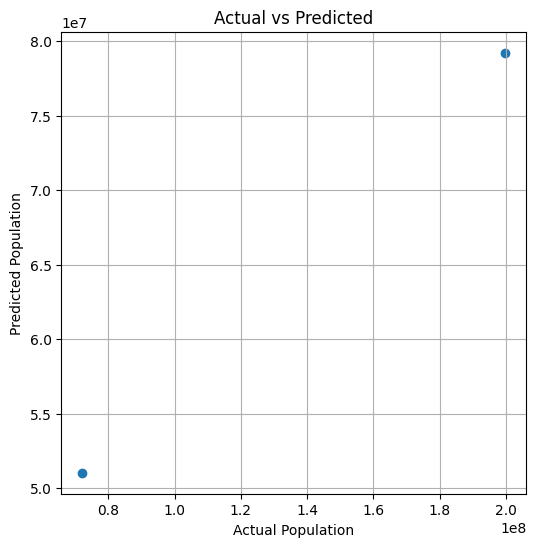

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Population")
plt.ylabel("Predicted Population")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

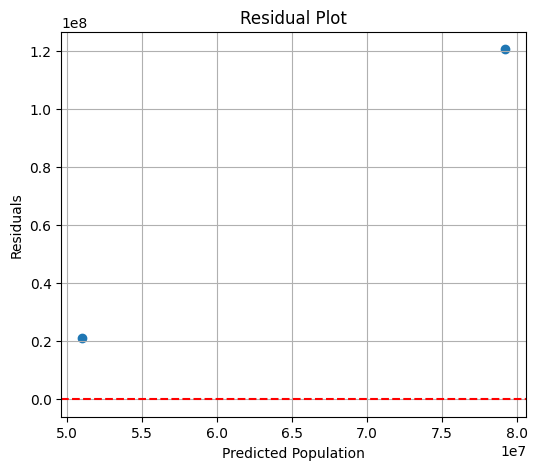

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Population")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [20]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

In [21]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

In [22]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "MSE": [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, lasso_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred)
    ],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]
})

results

,Model,MSE,RMSE,MAE,R2 Score
0,Linear Regression,7.494882e+15,8.657299e+07,7.085214e+07,-0.839412
1,Ridge,7.496131e+15,8.658020e+07,7.085881e+07,-0.839718
2,Lasso,7.494882e+15,8.657299e+07,7.085214e+07,-0.839412
